<a href="https://colab.research.google.com/github/minkyunglee-data/Portfolio/blob/Portfolio_Project/Bike_Sharing_Demand_Forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#EDA

In [96]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [97]:
train_df = pd.read_csv('/content/train.csv')

In [98]:
train_df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


In [99]:
#데이터 크기 확인
train_df.shape

(10886, 12)

In [100]:
#자료형 확인
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 1020.7+ KB


In [101]:
#결측치 확인
train_df.isnull().sum()

,0
datetime,0
season,0
holiday,0
workingday,0
weather,0
temp,0
atemp,0
humidity,0
windspeed,0
casual,0


In [102]:
# datetime 타입으로 변환
train_df['datetime'] = pd.to_datetime(train_df['datetime'])

#파생변수 생성
train_df['year'] = train_df['datetime'].dt.year
train_df['month'] = train_df['datetime'].dt.month
train_df['day'] = train_df['datetime'].dt.day
train_df['hour'] = train_df['datetime'].dt.hour
train_df['dayofweek']  = train_df['datetime'].dt.dayofweek
train_df['dayname'] = train_df['datetime'].dt.day_name()

train_df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,year,month,day,hour,dayofweek,dayname
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,2011,1,1,0,5,Saturday
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,2011,1,1,1,5,Saturday
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,2011,1,1,2,5,Saturday
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,2011,1,1,3,5,Saturday
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,2011,1,1,4,5,Saturday


In [103]:
#파일 저장
train_df.to_csv("Bike_Sharing_datetime.csv", index=False)

<ipython-input-104-36d0e73a651b>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data = train_df, x = 'season', palette = 'viridis')


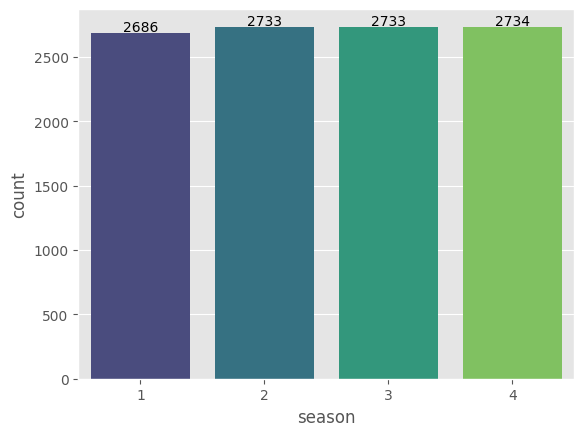

In [104]:
#1. season: 분기별(계절별) count 비슷
ax = sns.countplot(data = train_df, x = 'season', palette = 'viridis')
for index, value in enumerate (train_df.groupby('season')['count'].count()):
  ax.text(index, value + 15, round(value, 2), color = 'black', ha = "center")

plt.show()


<ipython-input-105-8febe6d09311>:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=train_df, x='workingday', y='count', palette=['#E74C3C', '#2980B9'])


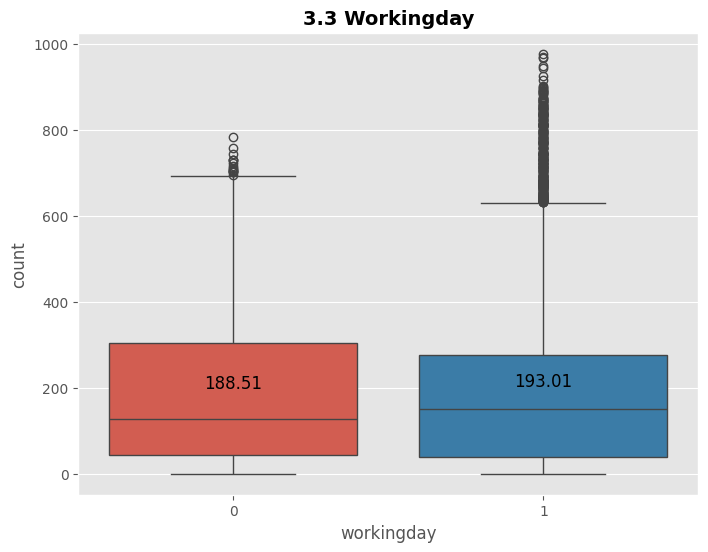

In [105]:
#2. workingday: 주말과 공휴일은 0, 주중은 1 기준으로  일하는 날의 수요가 많음 (출퇴근 시간 대여량 많은 것으로 추측)

# 그래프 스타일 설정
plt.style.use("ggplot")
plt.figure(figsize=(8, 6))

# 박스플롯 그리기
ax = sns.boxplot(data=train_df, x='workingday', y='count', palette=['#E74C3C', '#2980B9'])

# 박스플롯 위에 평균값 표시
means = train_df.groupby('workingday')['count'].mean()
for i, mean in enumerate(means):
    ax.text(i, mean + 10, f"{mean:.2f}", ha='center', color='black', fontsize=12)

# 제목 및 레이블 추가
plt.title("3.3 Workingday", fontsize=14, fontweight='bold')
plt.xlabel("workingday", fontsize=12)
plt.ylabel("count", fontsize=12)

plt.show()


<ipython-input-106-0e9fc8700ace>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data = train_df, x = 'weather', palette = 'viridis')


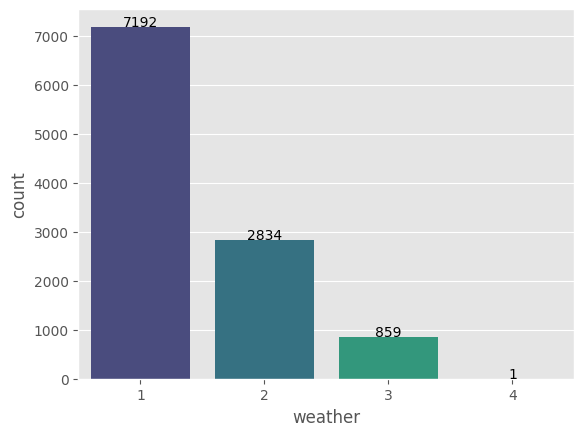

In [106]:
# 3. weather: 맑은 날의 대여수가 많음
# 1= 맑음, 2=안개+구름, 3=약간의 비나 눈, 4= 강우

#count
ax = sns.countplot(data = train_df, x = 'weather', palette = 'viridis')
for index, value in enumerate (train_df.groupby('weather')['count'].count()):
  ax.text(index, value + 15, round(value, 2), color = 'black', ha = "center")

plt.show()

<ipython-input-107-c76db36833ff>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=weather_mean.index, y=weather_mean.values,


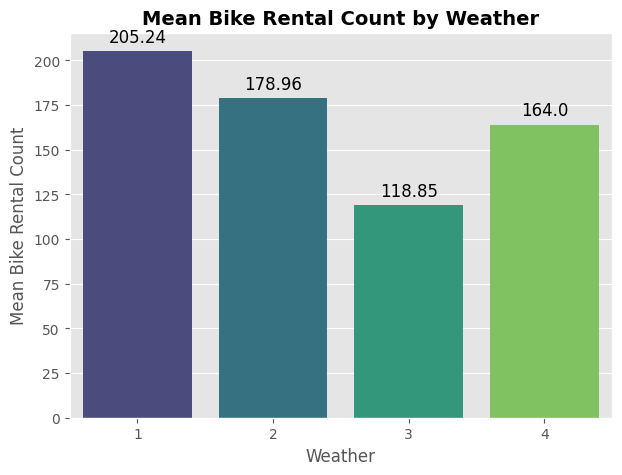

In [107]:
weather_mean = train_df.groupby('weather')['count'].mean()

fig, ax = plt.subplots(figsize=(7, 5))

sns.barplot(x=weather_mean.index, y=weather_mean.values,
            palette='viridis', ax=ax)

# 막대 위에 평균값 표시
for index, value in enumerate(weather_mean):
    ax.text(index, value + 5, f"{round(value, 2)}", ha="center", color='black', fontsize=12)

ax.set_title("Mean Bike Rental Count by Weather", fontsize=14, fontweight='bold')
ax.set_xlabel("Weather", fontsize=12)
ax.set_ylabel("Mean Bike Rental Count", fontsize=12)

plt.show()

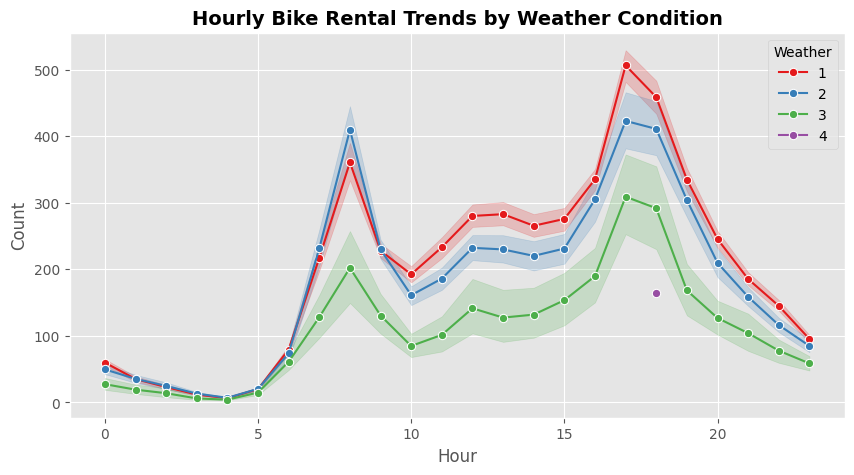

In [108]:
plt.figure(figsize=(10, 5))

# 시간(hour)별 평균 대여량을 weather별로 표현
sns.lineplot(data=train_df, x='hour', y='count', hue='weather', marker="o", palette="Set1")

plt.title("Hourly Bike Rental Trends by Weather Condition", fontsize=14, fontweight='bold')
plt.xlabel("Hour", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.legend(title="Weather")
plt.show()

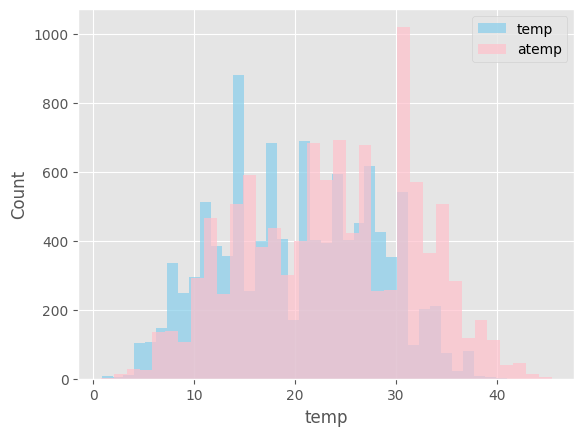

In [109]:
#4. temp, atemp: 온도와 체감온도가 매우 높거나 낮을 시 수요가 적고, 적정한 온도(섭씨 15-27도)에 수요가 가장 많음

sns.histplot(train_df, x='temp', kde=False, color='skyblue', linewidth=0, alpha=0.7, label = 'temp')
sns.histplot(train_df, x='atemp', kde=False, color='pink', linewidth=0, alpha=0.7, label = 'atemp')
plt.legend()
plt.show()

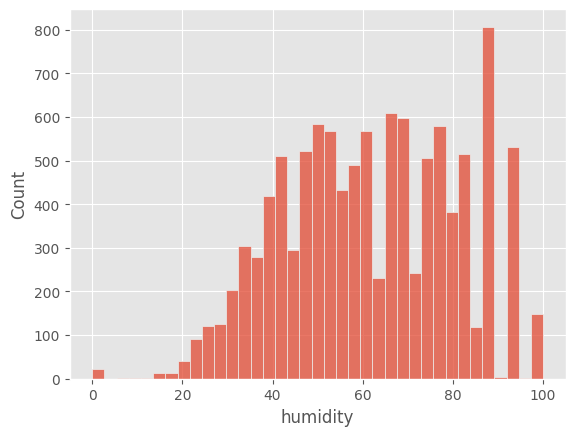

In [110]:
#5. Humidity: 습도는 낮을 때 대여량이 높고, 습도가 높아질수록(>60%) 대여량 감소
#6. Windspeed: 풍속은 큰 차이가 없으나, 극단적인 경우 사용량 줄어듦, 강품에도 출퇴근 수요가 있을 수 있음

sns.histplot(train_df, x = 'humidity')
plt.show()

<ipython-input-111-800ff0512196>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train_df, x='humidity_level', y='count', palette='OrRd')


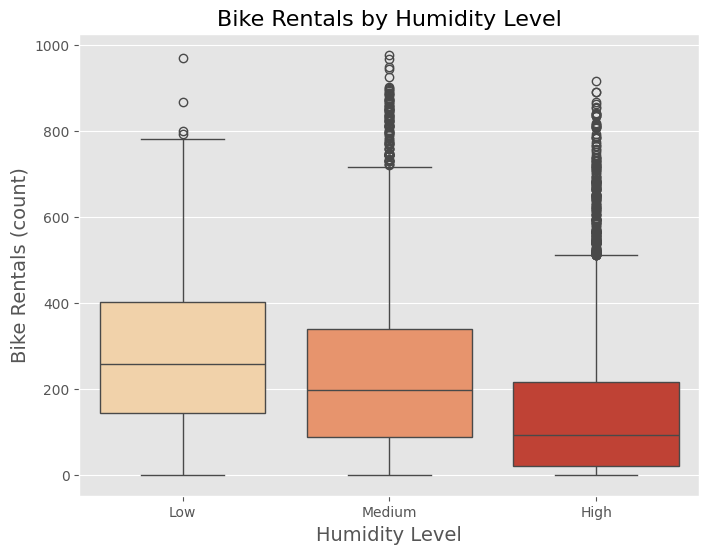

In [111]:
# 습도를 구간별로 나누기 (0-30: 낮음, 31-60: 중간, 61-100: 높음)
train_df['humidity_level'] = pd.cut(train_df['humidity'], bins=[0, 30, 60, 100], labels=['Low', 'Medium', 'High'])

plt.figure(figsize=(8, 6))
sns.boxplot(data=train_df, x='humidity_level', y='count', palette='OrRd')

plt.xlabel("Humidity Level", fontsize=14)
plt.ylabel("Bike Rentals (count)", fontsize=14)
plt.title("Bike Rentals by Humidity Level", fontsize=16)
plt.show()

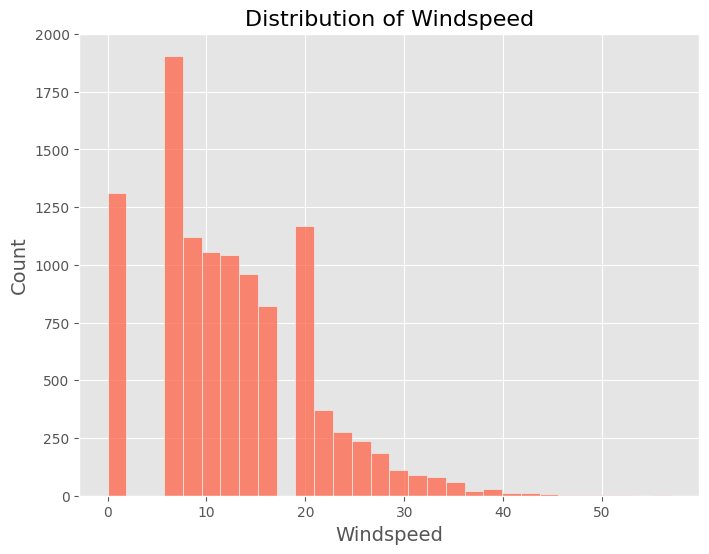

In [112]:
plt.figure(figsize=(8,6))

# bins 값 증가 (막대 개수 늘리기)
sns.histplot(train_df['windspeed'], bins=30, color='tomato', kde=False)

plt.xlabel("Windspeed", fontsize=14)
plt.ylabel("Count", fontsize=14)
plt.title("Distribution of Windspeed", fontsize=16)
plt.show()

In [113]:
print(train_df['windspeed'].describe())


count    10886.000000
mean        12.799395
std          8.164537
min          0.000000
25%          7.001500
50%         12.998000
75%         16.997900
max         56.996900
Name: windspeed, dtype: float64


<ipython-input-114-345ce9944112>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train_df, x='dayname', y='count', palette='Set2', ax=axes[0])


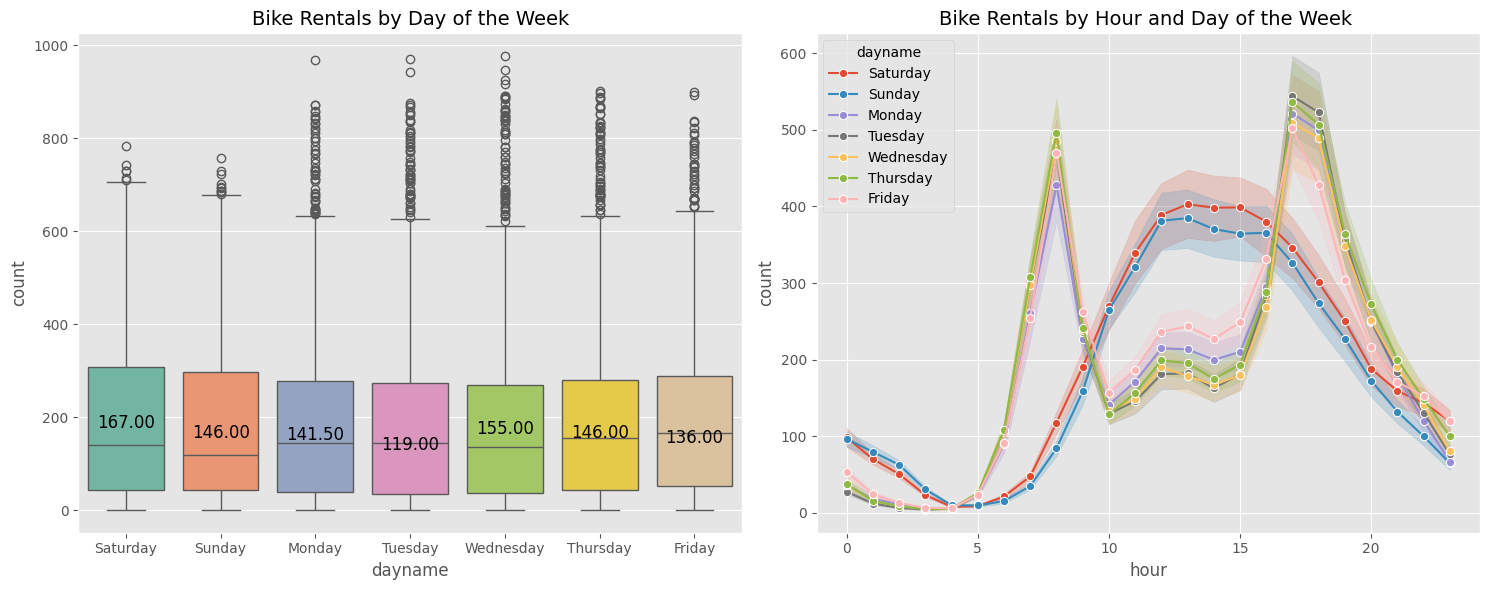

In [114]:
#7. 요일별 대여량: 요일별로 크게 수요의 차이가 없음
# 요일(dayname)별 대여량 박스플롯 & 시간대별 평균 대여량 선 그래프
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

#요일별 대여량 박스플롯
sns.boxplot(data=train_df, x='dayname', y='count', palette='Set2', ax=axes[0])

# 박스플롯 중앙값 라벨 추가
medians = train_df.groupby('dayname')['count'].median()
for i, median in enumerate(medians):
    axes[0].text(i, median + 10, f"{median:.2f}", ha='center', fontsize=12, color='black')

# 그래프 설정
axes[0].set_title("Bike Rentals by Day of the Week", fontsize=14)
axes[0].set_xlabel("dayname", fontsize=12)
axes[0].set_ylabel("count", fontsize=12)

#8. 시간대별 대여량: 평일은 출퇴근 시간에 수요가 가장 많음
sns.lineplot(data=train_df, x='hour', y='count', hue='dayname', marker='o', ax=axes[1])

# 그래프 설정
axes[1].set_title("Bike Rentals by Hour and Day of the Week ", fontsize=14)
axes[1].set_xlabel("hour", fontsize=12)
axes[1].set_ylabel("count", fontsize=12)
axes[1].legend(title="dayname")

plt.tight_layout()
plt.show()

<ipython-input-115-9165827b056d>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train_df, x='hour', y='count', palette='viridis')


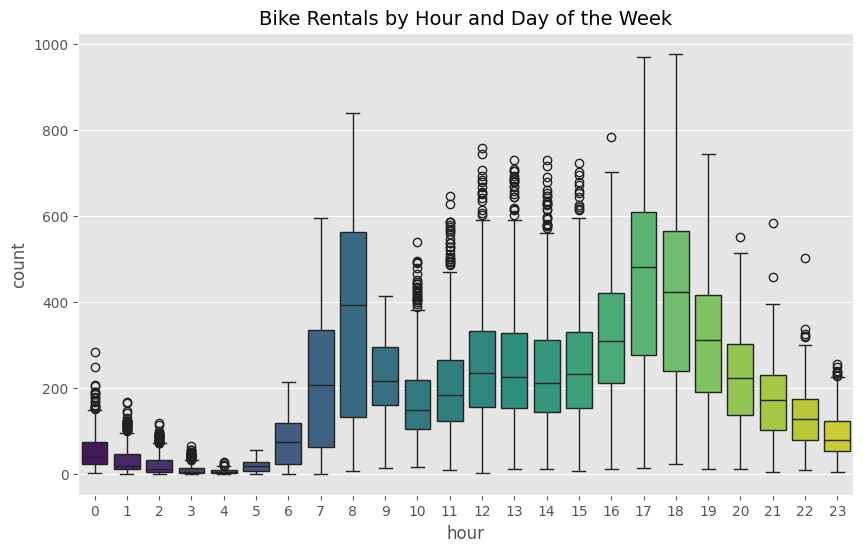

In [115]:
#8. 시간대별 대여량: 평일은 출퇴근 시간에 수요가 가장 많음
#전체 시간대별 박스플롯
plt.figure(figsize=(10, 6))
sns.boxplot(data=train_df, x='hour', y='count', palette='viridis')
plt.title("Bike Rentals by Hour and Day of the Week", fontsize=14)
plt.xlabel("hour", fontsize=12)
plt.ylabel("count", fontsize=12)
plt.show()


<ipython-input-116-39ec0e4e834d>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train_df[train_df['workingday'] == 1], x='hour', y='count', palette='coolwarm', ax=axes[0])
<ipython-input-116-39ec0e4e834d>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train_df[train_df['workingday'] == 0], x='hour', y='count', palette='coolwarm', ax=axes[1])


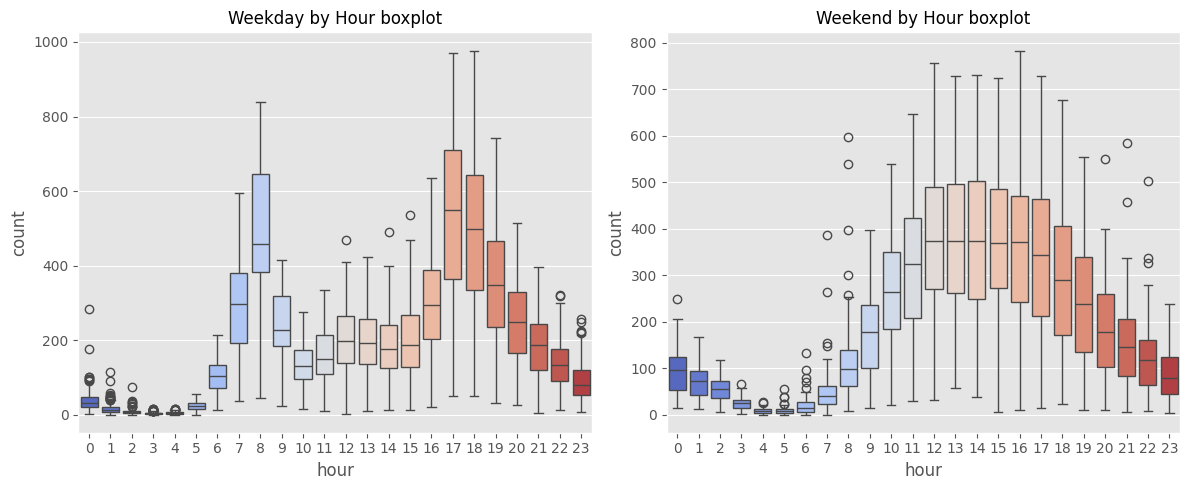

In [116]:
# 평일과 주말을 나누어 박스플롯 생성
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 평일 (workingday=1)
sns.boxplot(data=train_df[train_df['workingday'] == 1], x='hour', y='count', palette='coolwarm', ax=axes[0])
axes[0].set_title("Weekday by Hour boxplot", fontsize=12)

# 주말 (workingday=0)
sns.boxplot(data=train_df[train_df['workingday'] == 0], x='hour', y='count', palette='coolwarm', ax=axes[1])
axes[1].set_title("Weekend by Hour boxplot", fontsize=12)

plt.tight_layout()
plt.show()

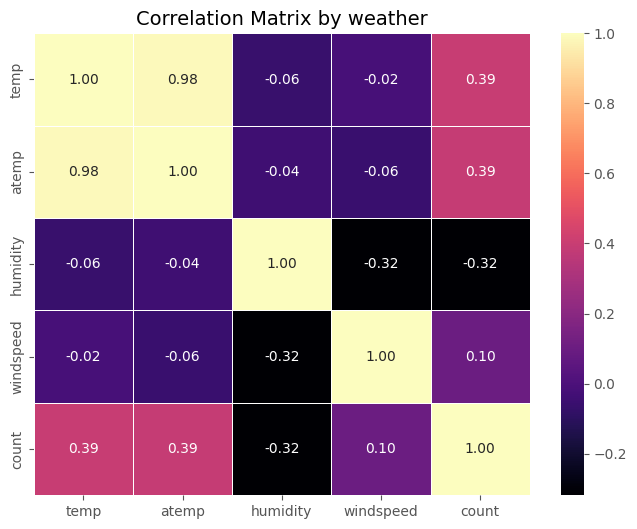

In [117]:
#상관계수 계산: 온도, 체감온도 상관관계 높음
corr_matrix = train_df[['temp', 'atemp', 'humidity', 'windspeed', 'count']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="magma", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix by weather", fontsize=14)
plt.show()


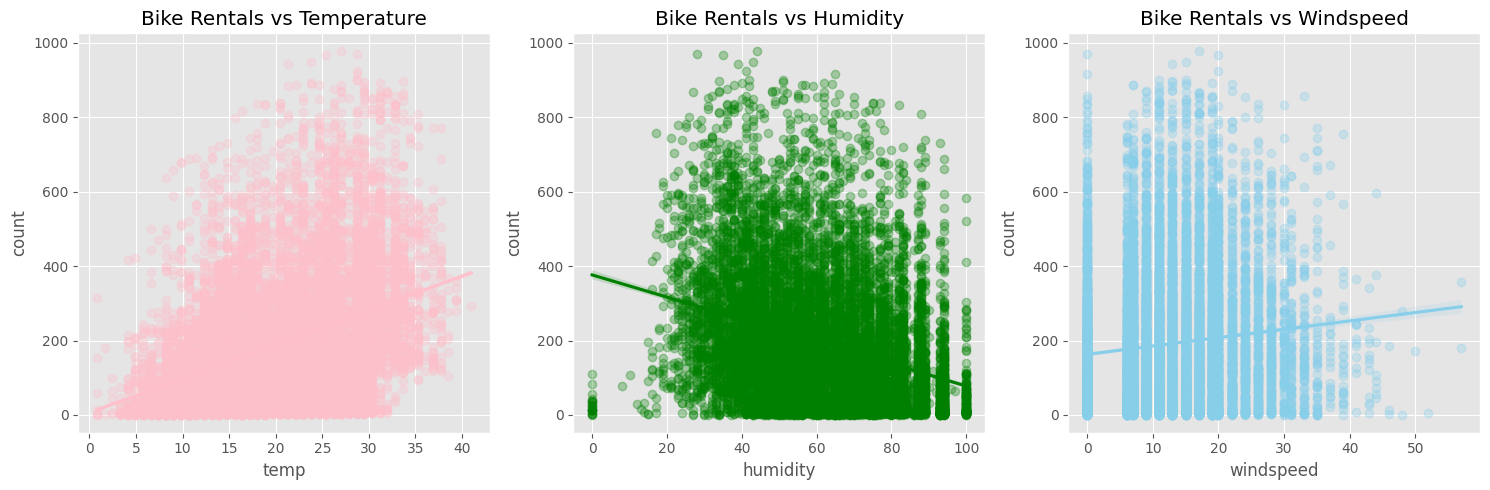

In [118]:
#산점도 플롯
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 온도(temp) vs 대여량
sns.regplot(x='temp', y='count', data=train_df, scatter_kws={'alpha':0.3}, color='pink', ax=axes[0])
axes[0].set_title("Bike Rentals vs Temperature")

# 습도(humidity) vs 대여량
sns.regplot(x='humidity', y='count', data=train_df, scatter_kws={'alpha':0.3}, color='green', ax=axes[1])
axes[1].set_title("Bike Rentals vs Humidity")

# 풍속(windspeed) vs 대여량
sns.regplot(x='windspeed', y='count', data=train_df, scatter_kws={'alpha':0.3}, color='skyblue', ax=axes[2])
axes[2].set_title("Bike Rentals vs Windspeed")

plt.tight_layout()
plt.show()

<ipython-input-119-c135b5e7b815>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train_df, x='month', y='count', palette='Set3', ax=axes[0])
<ipython-input-119-c135b5e7b815>:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train_df, x='season', y='count', palette='Set2', ax=axes[1])


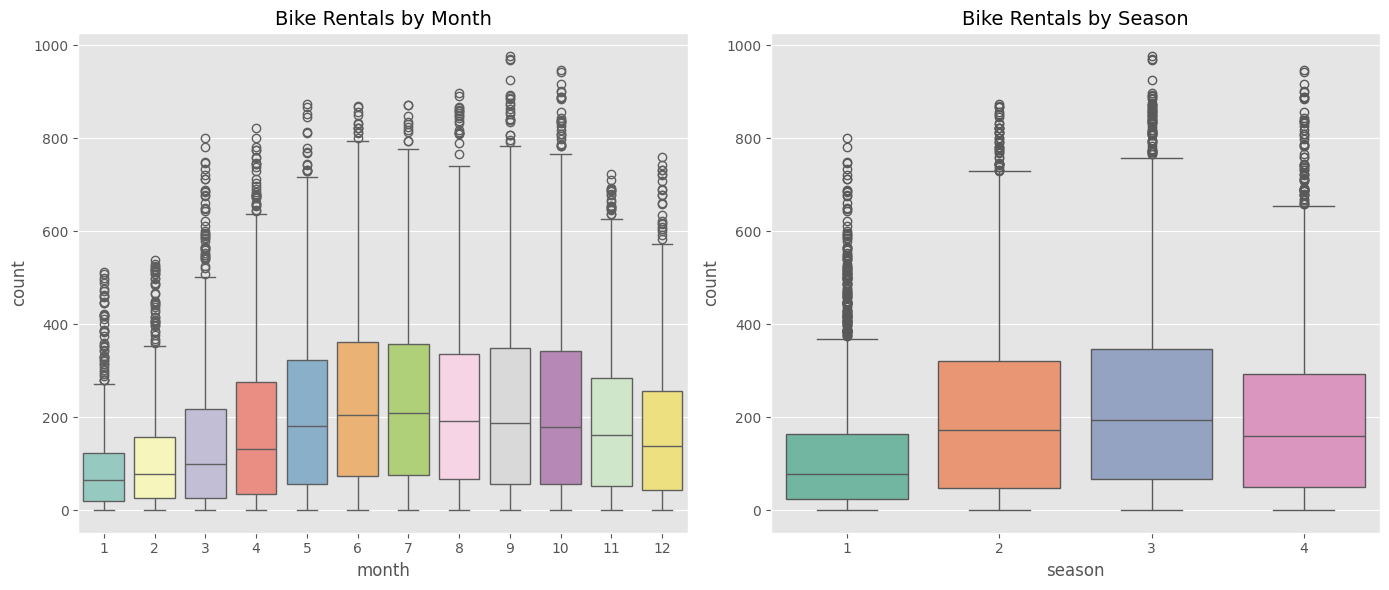

In [119]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 월별 대여량 박스플롯
sns.boxplot(data=train_df, x='month', y='count', palette='Set3', ax=axes[0])
axes[0].set_title("Bike Rentals by Month", fontsize=14)
axes[0].set_xlabel("month", fontsize=12)
axes[0].set_ylabel("count", fontsize=12)

# 계절별 대여량 박스플롯
sns.boxplot(data=train_df, x='season', y='count', palette='Set2', ax=axes[1])
axes[1].set_title("Bike Rentals by Season", fontsize=14)
axes[1].set_xlabel("season", fontsize=12)
axes[1].set_ylabel("count", fontsize=12)

plt.tight_layout()
plt.show()

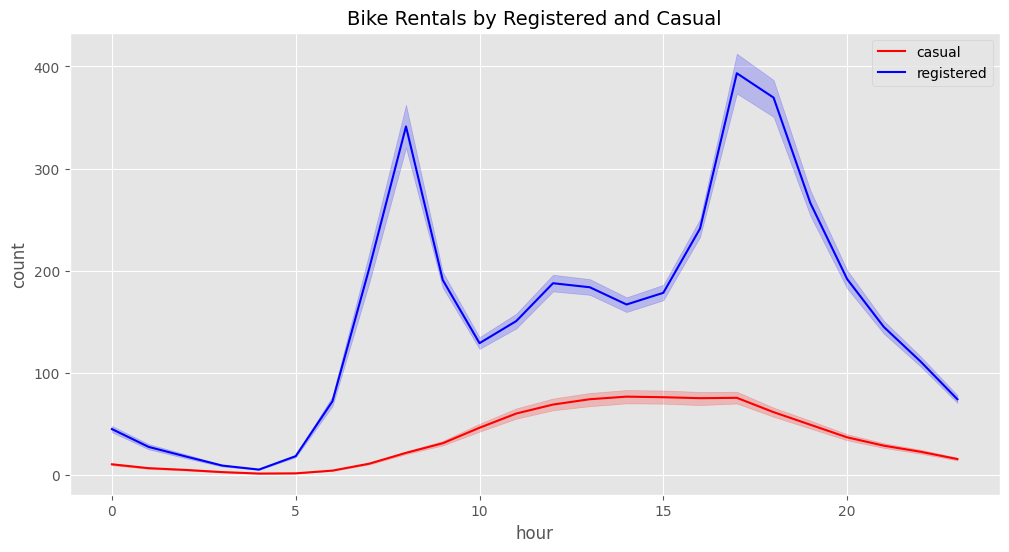

In [120]:
# 회원 vs 비회원 대여량 시각화
plt.figure(figsize=(12, 6))
sns.lineplot(data=train_df, x='hour', y='casual', label="casual", color="red")
sns.lineplot(data=train_df, x='hour', y='registered', label="registered", color="blue")

plt.title("Bike Rentals by Registered and Casual", fontsize=14)
plt.xlabel("hour", fontsize=12)
plt.ylabel("count", fontsize=12)
plt.legend()
plt.show()

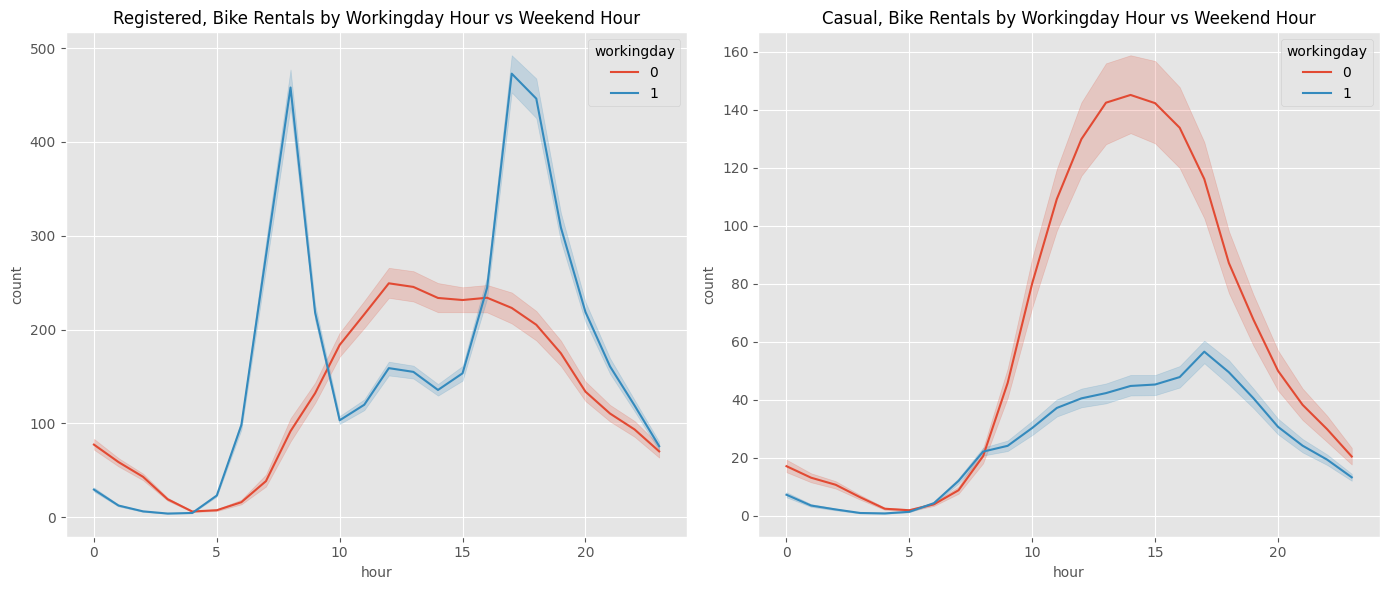

In [121]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 회원(registered) 대여량
sns.lineplot(data=train_df, x='hour', y='registered', hue='workingday', ax=axes[0])
axes[0].set_title("Registered, Bike Rentals by Workingday Hour vs Weekend Hour", fontsize=12)
axes[0].set_xlabel("hour", fontsize=10)
axes[0].set_ylabel("count", fontsize=10)

# 비회원(casual) 대여량
sns.lineplot(data=train_df, x='hour', y='casual', hue='workingday', ax=axes[1])
axes[1].set_title("Casual, Bike Rentals by Workingday Hour vs Weekend Hour", fontsize=12)
axes[1].set_xlabel("hour", fontsize=10)
axes[1].set_ylabel("count", fontsize=10)

plt.tight_layout()
plt.show()

#Data Preparation

In [123]:
df = pd.read_csv('/content/Bike_Sharing_datetime.csv')

df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,year,month,day,hour,dayofweek,dayname
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,2011,1,1,0,5,Saturday
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,2011,1,1,1,5,Saturday
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,2011,1,1,2,5,Saturday
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,2011,1,1,3,5,Saturday
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,2011,1,1,4,5,Saturday


In [125]:
# 범주형데이터 및 datetime 제거

df.drop(['datetime', 'dayname'], axis = 1, inplace = True)


In [126]:
#후보변수 선택
#상관계수 도출
abs(df.corr())

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,year,month,day,hour,dayofweek
season,1.000000,0.029368,0.008126,0.008879,0.258689,0.264744,0.190610,0.147121,0.096758,0.164011,0.163439,0.004797,0.971524,0.001729,0.006546,0.010553
holiday,0.029368,1.000000,0.250491,0.007074,0.000295,0.005215,0.001929,0.008409,0.043799,0.020956,0.005393,0.012021,0.001731,0.015877,0.000354,0.191832
workingday,0.008126,0.250491,1.000000,0.033772,0.029966,0.024660,0.010880,0.013373,0.319111,0.119460,0.011594,0.002482,0.003394,0.009829,0.002780,0.704267
weather,0.008879,0.007074,0.033772,1.000000,0.055035,0.055376,0.406244,0.007261,0.135918,0.109340,0.128655,0.012548,0.012144,0.007890,0.022740,0.047692
temp,0.258689,0.000295,0.029966,0.055035,1.000000,0.984948,0.064949,0.017852,0.467097,0.318571,0.394454,0.061226,0.257589,0.015551,0.145430,0.038466
atemp,0.264744,0.005215,0.024660,0.055376,0.984948,1.000000,0.043536,0.057473,0.462067,0.314635,0.389784,0.058540,0.264173,0.011866,0.140343,0.040235
humidity,0.190610,0.001929,0.010880,0.406244,0.064949,0.043536,1.000000,0.318607,0.348187,0.265458,0.317371,0.078606,0.204537,0.011335,0.278011,0.026507
windspeed,0.147121,0.008409,0.013373,0.007261,0.017852,0.057473,0.318607,1.000000,0.092276,0.091052,0.101369,0.015221,0.150192,0.036157,0.146631,0.024804
casual,0.096758,0.043799,0.319111,0.135918,0.467097,0.462067,0.348187,0.092276,1.000000,0.497250,0.690414,0.145241,0.092722,0.014109,0.302045,0.246959
registered,0.164011,0.020956,0.119460,0.109340,0.318571,0.314635,0.265458,0.091052,0.497250,1.000000,0.970948,0.264265,0.169451,0.019111,0.380540,0.084427


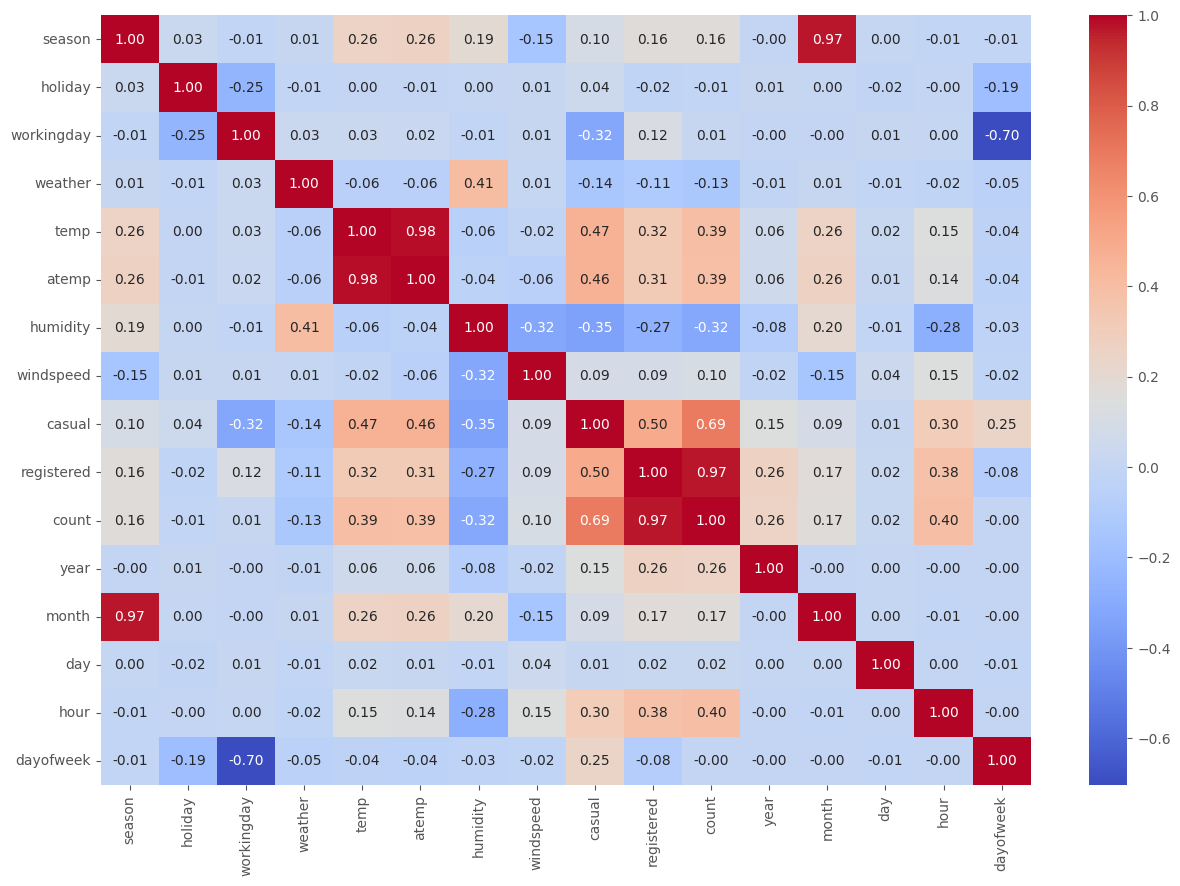

In [127]:
plt.figure(figsize = (15,10))
sns.heatmap(df.corr(), annot = True, fmt = ".2f", cmap = 'coolwarm')
plt.show()

In [130]:
# season, weather는 범주형이므로 더미변수 생성하여 원핫인코딩
#앞의 결과대로 체감온도(atemp), 회원(registered), 비회원(Casual) 제거
df.drop(['atemp','casual','registered','month'], inplace=True, axis = 1)
df.head()

,season,holiday,workingday,weather,temp,humidity,windspeed,count,year,day,hour,dayofweek
0,1,0,0,1,9.84,81,0.0,16,2011,1,0,5
1,1,0,0,1,9.02,80,0.0,40,2011,1,1,5
2,1,0,0,1,9.02,80,0.0,32,2011,1,2,5
3,1,0,0,1,9.84,75,0.0,13,2011,1,3,5
4,1,0,0,1,9.84,75,0.0,1,2011,1,4,5


In [131]:
#one-hot encoding
df = pd.get_dummies(df, columns = ['season', 'weather'])
df.head()

,holiday,workingday,temp,humidity,windspeed,count,year,day,hour,dayofweek,season_1,season_2,season_3,season_4,weather_1,weather_2,weather_3,weather_4
0,0,0,9.84,81,0.0,16,2011,1,0,5,True,False,False,False,True,False,False,False
1,0,0,9.02,80,0.0,40,2011,1,1,5,True,False,False,False,True,False,False,False
2,0,0,9.02,80,0.0,32,2011,1,2,5,True,False,False,False,True,False,False,False
3,0,0,9.84,75,0.0,13,2011,1,3,5,True,False,False,False,True,False,False,False
4,0,0,9.84,75,0.0,1,2011,1,4,5,True,False,False,False,True,False,False,False


In [132]:
#다중공선성 분석
cols = ['holiday', 'workingday', 'temp', 'humidity', 'windspeed',
        'count', 'year', 'day', 'dayofweek', 'hour']

abs(df[cols].corr()['count']).sort_values(ascending=False)

,count
count,1.000000
hour,0.400601
temp,0.394454
humidity,0.317371
year,0.260403
windspeed,0.101369
day,0.019826
workingday,0.011594
holiday,0.005393
dayofweek,0.002283


In [135]:
#VIF계산: 보통 10이 넘으면 다중공선성이 있다고 판단함
#Year제거

from statsmodels.stats.outliers_influence import variance_inflation_factor
vif = pd.DataFrame()

vif["VIF Factor"] = [variance_inflation_factor(df[cols].values, i) for i in range(df[cols].shape[1])]
vif["features"] = df[cols].columns

# VIF 값이 높은 순으로 정렬
vif = vif.sort_values(by="VIF Factor", ascending=False)
vif = vif.reset_index(drop=True)  # index 제거 후 재정렬

# 결과 출력
vif

,VIF Factor,features
0,62.401205,year
1,14.297499,humidity
2,9.247324,temp
3,9.129554,dayofweek
4,8.993159,workingday
5,4.671493,hour
6,4.339517,day
7,3.885421,windspeed
8,3.108844,count
9,1.543113,holiday


In [136]:
#Year제거
df.drop(['year'], inplace = True, axis = 1)


In [137]:
cols = ['holiday', 'workingday', 'temp', 'humidity', 'windspeed',
        'count', 'day', 'dayofweek', 'hour']

vif = pd.DataFrame()

vif["VIF Factor"] = [variance_inflation_factor(df[cols].values, i) for i in range(df[cols].shape[1])]
vif["features"] = df[cols].columns

# VIF 값이 높은 순으로 정렬
vif = vif.sort_values(by="VIF Factor", ascending=False)
vif = vif.reset_index().drop(columns="index")
vif

,VIF Factor,features
0,8.963129,humidity
1,8.455013,temp
2,5.579647,workingday
3,5.452111,dayofweek
4,4.387811,hour
5,4.114888,day
6,3.397060,windspeed
7,3.099466,count
8,1.299584,holiday


In [138]:
#데이터셋 준비

from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(df.drop(['count'], axis=1), df['count'], test_size=0.25)

x_train.shape, x_test.shape, y_train.shape, y_test.shape

((8164, 16), (2722, 16), (8164,), (2722,))

#모델링

## LinearRegression

In [139]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# 모델 생성
lr_model = LinearRegression()

# 모델 훈련 (훈련 데이터 사용)
lr_model.fit(x_train, y_train)

# 모델의 학습 결과 (기울기, 절편)
print(f'''모델의 훈련 결과
coef: {lr_model.coef_}
intercept: {lr_model.intercept_}
''')

# 모델 평가 (테스트 데이터로 예측)
test_predict = lr_model.predict(x_test)

# 실제값과 예측값을 이용한 모델 평가
print('R²:', r2_score(y_test, test_predict))
print('MSE:', mean_squared_error(y_test, test_predict))

# R-Squared의 값이 0.33으로 너무 낮아서 제외

모델의 훈련 결과
coef: [ -1.0966133    2.25437264   9.27834756  -2.06360625  -0.09933528
   0.3484293    7.56448105   0.78374994 -16.96137941  -0.34924814
 -31.17037259  48.48100014 -22.42881919  -9.92072933 -49.45967247
  81.80922099]
intercept: 59.58528021044407

R²: 0.3323046983278227
MSE: 21796.103763666186


##KNeighborsRegressor

In [141]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_squared_error

# 모델 생성
knr_model = KNeighborsRegressor()

# 모델 훈련 (훈련 데이터 사용)
knr_model.fit(x_train, y_train)

# 모델 평가 (테스트 데이터로 예측)
test_predict = knr_model.predict(x_test)

# 실제값과 예측값을 이용한 모델 평가
print('R²:', r2_score(y_test, test_predict))
print('MSE:', mean_squared_error(y_test, test_predict))

#R-Squared 값이 선형회귀모델보다는 낫지만 0.55로 여전히 낮음, 제외

R²: 0.558317861106626
MSE: 14418.178030859663


##DecisionTreeRegressor

R²: 0.7527404739019463
MSE: 8071.487509184423


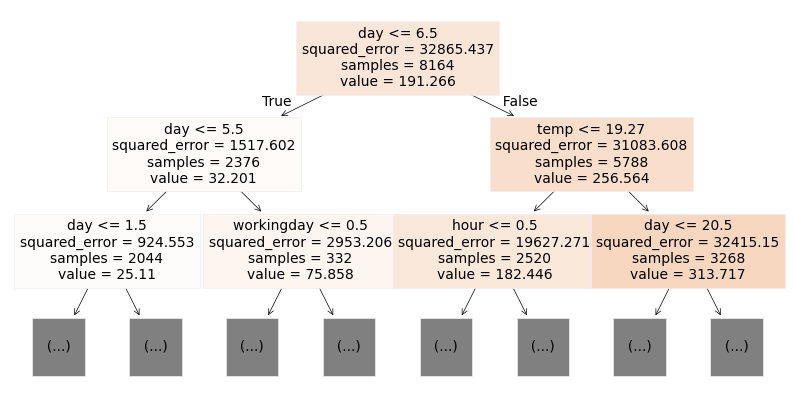

In [143]:
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt

# 모델 생성
dtr_model = DecisionTreeRegressor()

# 모델 훈련 (훈련 데이터 사용)
dtr_model.fit(x_train, y_train)

# 트리 구조 시각화
plt.figure(figsize=(10,5))
plot_tree(dtr_model, filled=True, feature_names=cols, fontsize=10, max_depth=2)

# 모델 평가 (테스트 데이터로 예측)
test_predict = dtr_model.predict(x_test)

# 실제값과 예측값을 이용한 모델 평가
print('R²:', r2_score(y_test, test_predict))
print('MSE:', mean_squared_error(y_test, test_predict))

#R-Squared 값이 0.746으로 앞의 KNR 보다 높음

##RandomForest

In [144]:

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

# 모델 생성
rfr_model = RandomForestRegressor()

# 모델 훈련 (훈련 데이터 사용)
rfr_model.fit(x_train, y_train)

# 모델 평가 (테스트 데이터로 예측)
test_predict = rfr_model.predict(x_test)

# 실제값과 예측값을 이용한 모델 평가
print('R²:', r2_score(y_test, test_predict))
print('MSE:', mean_squared_error(y_test, test_predict))


#R-Squared 값이 0.87으로 가장 높음

R²: 0.866697189827509
MSE: 4351.508652571639


##K-fold 교차검증

In [146]:
#LinearRegression

from sklearn.model_selection import KFold
k=5
kf = KFold(n_splits=k, shuffle=True)

# 모델 생성 함수
def fn_model_create(x,y):
    # sklearn의 linear_model 모듈의 LinearRegression 객체 생성
    lr = LinearRegression()
    lr.fit(x, y)
    return lr

# k-fold 교차검증
r2_score_list = []
mse_list = []
for train_idx, test_idx in kf.split(df.drop(['count'], axis=1), df['count']):
    x_train, y_train = df.drop(['count'], axis=1).iloc[train_idx], df['count'][train_idx]
    x_test, y_test = df.drop(['count'], axis=1).iloc[test_idx], df['count'][test_idx]

    # 훈련 데이터로 학습
    model = fn_model_create(x_train, y_train)

    # 테스트 데이터로 평가하여 리스트에 추가
    test_predict = model.predict(x_test)
    r2_score_list.append(r2_score(y_test, test_predict))
    mse_list.append(mean_squared_error(y_test, test_predict))

print(f'''
r2_score : {sum(r2_score_list)/k}
mse : {sum(mse_list)/k}
''')


r2_score : 0.3444734540737382
mse : 21490.241553676933



In [147]:
#KNR
k=5
kf = KFold(n_splits=k, shuffle=True)

# 모델 생성 함수
def fn_model_create(x,y):
    # sklearn의 neighbors 모듈의 KNeighborsRegressor 객체 생성
    model = KNeighborsRegressor()
    model.fit(x, y)
    return model

# k-fold 교차검증
r2_score_list = []
mse_list = []
for train_idx, test_idx in kf.split(df.drop(['count'], axis=1), df['count']):
    x_train, y_train = df.drop(['count'], axis=1).iloc[train_idx], df['count'][train_idx]
    x_test, y_test = df.drop(['count'], axis=1).iloc[test_idx], df['count'][test_idx]

    # 훈련 데이터로 학습
    model = fn_model_create(x_train, y_train)

    # 테스트 데이터로 평가하여 리스트에 추가
    test_predict = model.predict(x_test)
    r2_score_list.append(r2_score(y_test, test_predict))
    mse_list.append(mean_squared_error(y_test, test_predict))

print(f'''
r2_score : {sum(r2_score_list)/k}
mse : {sum(mse_list)/k}
''')


r2_score : 0.553919473756791
mse : 14627.547815358243



In [148]:
#DecisionTreeRegressor
k=5
kf = KFold(n_splits=k, shuffle=True)

# 모델 생성 함수
def fn_model_create(x,y):
    # sklearn의 tree 모듈의 DecisionTreeRegressor 객체 생성
    model = DecisionTreeRegressor()
    model.fit(x, y)
    return model

# k-fold 교차검증
r2_score_list = []
mse_list = []
for train_idx, test_idx in kf.split(df.drop(['count'], axis=1), df['count']):
    x_train, y_train = df.drop(['count'], axis=1).iloc[train_idx], df['count'][train_idx]
    x_test, y_test = df.drop(['count'], axis=1).iloc[test_idx], df['count'][test_idx]

    # 훈련 데이터로 학습
    model = fn_model_create(x_train, y_train)

    # 테스트 데이터로 평가하여 리스트에 추가
    test_predict = model.predict(x_test)
    r2_score_list.append(r2_score(y_test, test_predict))
    mse_list.append(mean_squared_error(y_test, test_predict))

print(f'''
r2_score : {sum(r2_score_list)/k}
mse : {sum(mse_list)/k}
''')


r2_score : 0.7468650374474756
mse : 8286.290712107082



In [149]:
#RandomForestRegressor: R-Squared_score도 랜덤포레스트 모델이 가장 높음
k=5
kf = KFold(n_splits=k, shuffle=True)

# 모델 생성 함수
def fn_model_create(x,y):
    # sklearn의 ensemble 모듈의 RandomForestRegressor 객체 생성
    model = RandomForestRegressor()
    model.fit(x, y)
    return model

# k-fold 교차검증
r2_score_list = []
mse_list = []
for train_idx, test_idx in kf.split(df.drop(['count'], axis=1), df['count']):
    x_train, y_train = df.drop(['count'], axis=1).iloc[train_idx], df['count'][train_idx]
    x_test, y_test = df.drop(['count'], axis=1).iloc[test_idx], df['count'][test_idx]

    # 훈련 데이터로 학습
    model = fn_model_create(x_train, y_train)

    # 테스트 데이터로 평가하여 리스트에 추가
    test_predict = model.predict(x_test)
    r2_score_list.append(r2_score(y_test, test_predict))
    mse_list.append(mean_squared_error(y_test, test_predict))

print(f'''
r2_score : {sum(r2_score_list)/k}
mse : {sum(mse_list)/k}
''')


r2_score : 0.8690632469704888
mse : 4299.533338915041



##etc